# Семинар 4. Условная генерация: перевод и оценка качества

Сегодня возьмем готовую seq2seq-модель машинного перевода и разберем ее - от токенизации входного текста до выбора следующего токена при генерации.

## Что мы сделаем

1. **Разберем seq2seq как условную языковую модель.** Свяжем знакомое нам авторегрессионное порождение с условной вероятностью $P(Y\mid X)$ и посмотрим, как encoder-decoder архитектура использует исходный текст при генерации перевода.

2. **Посмотрим, как модель читает вход.** Разберем подсловную токенизацию и увидим, почему подсловное представление помогает работать с редкими словами, именами, числами и терминами без постоянного использования `<UNK>`.

3. **Заглянем внутрь cross-attention.** Визуализируем веса внимания и попробуем увидеть, какие части исходного предложения модель учитывает при генерации отдельных токенов перевода. Заодно обсудим, почему attention нельзя напрямую считать строгим выравниванием слов.

4. **Сравним стратегии декодирования.** Проверим, чем отличаются `greedy`, `beam search` и `sampling`, и увидим, почему одна и та же модель может выдавать разные переводы без изменения своих весов.

5. **Разберем teacher forcing и loss.** Посчитаем кросс-энтропию для эталонного перевода и обсудим, чем обучение отличается от генерации и откуда возникает проблема exposure bias.

6. **Оценим качество.** Посчитаем BLEU с помощью `sacrebleu`, сравним результаты разных стратегий декодирования и разберемся, почему изменение способа генерации меняет метрику, хотя модель остается той же.

7. **Разберем ограничения автоматических метрик.** На конкретных примерах увидим, почему высокий BLEU не гарантирует корректность перевода, а хороший перефраз может получить низкую оценку. Обсудим, когда нужны другие метрики и почему человеческая оценка по-прежнему важна.


## Блок 0. Подготовка окружения

In [1]:
!pip install -q "transformers>=4.40" sentencepiece sacrebleu torch matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 kB 4.7 MB/s eta 0:00:00


Загружаем готовую модель машинного перевода EN-RU - `Helsinki-NLP/opus-mt-en-ru`. Это компактная модель семейства MarianMT из проекта OPUS-MT. Она построена на классической архитектуре encoder-decoder с механизмом cross-attention.


In [2]:
import torch, random, numpy as np
from transformers import MarianMTModel, MarianTokenizer

MODEL_NAME = "Helsinki-NLP/opus-mt-en-ru"
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
# чтобы модель отдавала веса внимания, нужна eager-реализация attention
model = MarianMTModel.from_pretrained(MODEL_NAME, attn_implementation="eager").to(device).eval()

def set_seed(s=42):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
set_seed()

print("Устройство:", device)
print("Это seq2seq (encoder-decoder)?", model.config.is_encoder_decoder)
print(f"Слоев в энкодере: {model.config.encoder_layers}")
print(f"Слоев в декодере: {model.config.decoder_layers}")
print(f"Размер словаря |V|: {model.config.vocab_size}")

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/803k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


...

model.safetensors: reconstructing file:   0%|          |  0.00B /  307MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Устройство: cpu
Это seq2seq (encoder-decoder)? True
Слоев в энкодере: 6
Слоев в декодере: 6
Размер словаря |V|: 62518


**Сквозные примеры.** Возьмем несколько английских предложений, которые будем пропускать через модель на протяжении всего семинара. Они подобраны неслучайно: в них встречаются имена, числа, редкие слова и необычный порядок слов. Позже увидим, как эти особенности влияют на работу модели.

In [3]:
EXAMPLES = [
    "The red car quickly passed the old bridge.", # порядок слов / прилагательные
    "Dr. Smith moved to Zurich in 2019 and joined DeepMind.", # имена, число, редкие сущности
    "I would like a cup of coffee, please.", # простая вежливая фраза
    "The meeting was postponed until next week." # к этому вернемся в блоке про BLEU
]
for s in EXAMPLES:
    print("EN:", s)

EN: The red car quickly passed the old bridge.
EN: Dr. Smith moved to Zurich in 2019 and joined DeepMind.
EN: I would like a cup of coffee, please.
EN: The meeting was postponed until next week.


## Блок 1. Seq2seq как условная генерация $P(Y\mid X)$

В лекции 1 мы рассматривали то, как языковая модель оценивала **безусловную** вероятность последовательности:

$$P(Y)=\prod_{t=1}^{T} P(y_t \mid y_{<t}).$$

Сегодня рассмотрим **условную** языковую модель. Теперь на каждом шаге модель дополнительно учитывает весь вход $X$:

$$P(Y\mid X)=\prod_{t=1}^{T} P(y_t \mid y_{<t},, X).$$

Основная идея остается знакомой: модель генерирует последовательность токен за токеном, а обучение по-прежнему основано на кросс-энтропии. Главное отличие в том, что при генерации модель учитывает не только уже сгенерированные токены $y_{<t}$, но и входную последовательность $X$.

Перевод, суммаризацию и перефразирование можно рассматривать как задачи одного общего типа - моделирование условной вероятности $P(Y\mid X)$. Они отличаются прежде всего данными, постановкой задачи и метриками оценки.

**Что делаем и на чем.** Подадим модели входную последовательность $X$ - английское предложение - и получим выходную последовательность $Y$ - русский перевод. По ходу семинара разберемся, как знакомое нам авторегрессионное порождение работает в условной модели и какую роль здесь играет вход $X$.

In [4]:
@torch.no_grad()
def translate(texts, **gen_kwargs):
    """X -> Y. По умолчанию — жадное декодирование (num_beams=1)."""
    if isinstance(texts, str):
        texts = [texts]
    batch = tokenizer(texts, return_tensors="pt", padding=True).to(device)
    gen_kwargs.setdefault("num_beams", 1) # greedy по умолчанию
    gen_kwargs.setdefault("max_new_tokens", 60)
    out = model.generate(**batch, **gen_kwargs)
    return tokenizer.batch_decode(out, skip_special_tokens=True)

for src, tgt in zip(EXAMPLES, translate(EXAMPLES)):
    print("EN:", src)
    print("RU:", tgt)
    print("-" * 60)

[transformers] Both `max_new_tokens` (=60) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


EN: The red car quickly passed the old bridge.
RU: Красная машина быстро прошла через старый мост.
------------------------------------------------------------
EN: Dr. Smith moved to Zurich in 2019 and joined DeepMind.
RU: В 2019 году доктор Смит переехал в Цюрих и присоединился к DeepMind.
------------------------------------------------------------
EN: I would like a cup of coffee, please.
RU: Я бы хотел чашку кофе, пожалуйста.
------------------------------------------------------------
EN: The meeting was postponed until next week.
RU: Совещание было перенесено на следующую неделю.
------------------------------------------------------------


Работает. Формально мы только что нашли приближение к

$$Y' = \arg\max_Y P(Y\mid X,\theta).$$

Теперь заглянем внутрь модели и убедимся, что генерация действительно происходит пошагово и авторегрессионно - как в обычной языковой модели, но с учетом входной последовательности $X$.

In [5]:
# Пошаговое порождение: на каждом шаге смотрим распределение P(y_t | y_<t, X)
@torch.no_grad()
def show_stepwise(text, n_steps=6, topk=5):
    enc = tokenizer([text], return_tensors="pt").to(device)
    encoder_outputs = model.get_encoder()(**enc) # X кодируется ОДИН раз
    dec_ids = torch.tensor([[model.config.decoder_start_token_id]], device=device)

    print(f"X = {text}\n")
    for step in range(n_steps):
        out = model(encoder_outputs=encoder_outputs, decoder_input_ids=dec_ids)
        probs = out.logits[0, -1].softmax(-1) # распределение по |V|
        top = probs.topk(topk)
        cands = [(tokenizer.convert_ids_to_tokens([i.item()])[0], f"{p:.2f}")
                 for p, i in zip(top.values, top.indices)]
        chosen_id = top.indices[0].item()
        chosen = tokenizer.convert_ids_to_tokens([chosen_id])[0]
        print(f"шаг {step+1}: top-{topk} = {cands}  -  выбираем '{chosen}'")
        dec_ids = torch.cat([dec_ids, torch.tensor([[chosen_id]], device=device)], dim=1)

    print("\nПрефикс перевода:", tokenizer.decode(dec_ids[0], skip_special_tokens=True))

show_stepwise("The red car quickly passed the old bridge.")

X = The red car quickly passed the old bridge.

шаг 1: top-5 = [('▁К', '0.58'), ('▁крас', '0.02'), ('▁Кра', '0.02'), ('▁Р', '0.02'), ('▁Красно', '0.02')]  -  выбираем '▁К'
шаг 2: top-5 = [('рас', '0.98'), ('ры', '0.00'), ('рова', '0.00'), ('л', '0.00'), ('ров', '0.00')]  -  выбираем 'рас'
шаг 3: top-5 = [('ная', '0.65'), ('ный', '0.21'), ('ную', '0.01'), ('ные', '0.01'), ('ной', '0.00')]  -  выбираем 'ная'
шаг 4: top-5 = [('▁машин', '0.92'), ('▁та', '0.01'), ('▁автомобиль', '0.00'), ('▁автомашин', '0.00'), ('▁авто', '0.00')]  -  выбираем '▁машин'
шаг 5: top-5 = [('а', '0.91'), ('ка', '0.00'), ('у', '0.00'), ('е', '0.00'), ('a', '0.00')]  -  выбираем 'а'
шаг 6: top-5 = [('▁быстро', '0.77'), ('▁скоро', '0.04'), ('▁сразу', '0.02'), (',', '0.01'), ('▁вскоре', '0.01')]  -  выбираем '▁быстро'

Префикс перевода: Красная машина быстро


На каждом шаге модель получает распределение вероятностей по всему словарю $|V|$ (`logits - softmax`) - так же, как в обычном языковом моделировании.

Энкодер обрабатывает вход $X$ один раз. Дальше на каждом шаге декодер обращается к полученному представлению входа через cross-attention. Представление $X$ при этом не пересчитывается во время генерации.

**Вопрос на подумать**

Что произойдет, если отключить энкодер и убрать у декодера доступ к $X$? Во что превратится такая модель? Сможет ли она переводить?


## Блок 2. Как модель читает вход: BPE-токенизация и cross-attention

**Вопрос**

В отзыве клиента встречается фраза `"...delivered to Zürich by DeepMind in 2019"`. Слов `Zürich` и `DeepMind` вполне может не быть в словаре модели как отдельных токенов. Что произойдет в таком случае: модель выбросит их или заменит на `<UNK>`? Почему при этом перевод все равно может сохранить эти названия?



Еще в Модуле 1 мы столкнулись с проблемой OOV (out-of-vocabulary): фиксированный словарь не может содержать все возможные слова. Для классификации это часто не критично - даже если отдельное слово неизвестно, модель может понять его роль по контексту. А вот в генерации потеря имени, числа или другого важного фрагмента означает потерю информации в ответе.

Решение - подсловная токенизация (например, BPE): вместо фиксированного набора целых слов модель использует открытый словарь (open vocabulary) из более мелких фрагментов. Незнакомое слово можно разбить на известные подслова, поэтому необходимость в `<UNK>` существенно уменьшается.

Это особенно важно для имен, чисел и других редких последовательностей: модель может представить их через отдельные подслова и использовать эту информацию при генерации перевода. Если нужные подслова встречаются и во входном, и в выходном языке, это также помогает модели сохранять такие фрагменты.

Посмотрим на это на практике.


In [15]:
sent = "Dr. Smith moved to Zurich in 2019 and joined DeepMind."
ids = tokenizer(sent).input_ids
pieces = tokenizer.convert_ids_to_tokens(ids)

print("Токенов:", len(pieces), "\n")
print(pieces, "\n")
# '▁' (U+2581) — маркер начала слова в SentencePiece. Слово, разбитое на части, показывает, что словарь именно ПОДсловный.
print("Как редкие сущности разбиты на подслова:")
for w in ["Zurich", "DeepMind", "2019"]:
    sub = tokenizer.convert_ids_to_tokens(tokenizer(w).input_ids)
    print(f"{w} -> {sub}")

Токенов: 16 

['▁Dr', '.', '▁Smith', '▁moved', '▁to', '▁Zurich', '▁in', '▁20', '19', '▁and', '▁joined', '▁Deep', 'Mi', 'nd', '.', '</s>'] 

Как редкие сущности разбиты на подслова:
Zurich -> ['▁Zurich', '</s>']
DeepMind -> ['▁Deep', 'Mi', 'nd', '</s>']
2019 -> ['▁20', '19', '</s>']


- Символ `▁` обозначает границу слова в SentencePiece. Частые слова могут оставаться целыми токенами, а редкие разбиваются на более мелкие подслова. Именно это позволяет работать с открытым словарем.
- Обратите внимание: `2019`, `Zurich` и `DeepMind` не превращаются в `<UNK>`. Модель может представить их последовательностями известных подслов, а затем использовать эту информацию при генерации перевода.

Переведем то же предложение. Как думаете, сохранит ли модель имя, название города, компанию и год?


In [17]:
print(translate("Dr. Smith moved to Zurich in 2019 and joined DeepMind.")[0])

[transformers] Both `max_new_tokens` (=60) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


В 2019 году доктор Смит переехал в Цюрих и присоединился к DeepMind.


При визуализации весов cross-attention часто можно увидеть что-то похожее на alignment - соответствие между фрагментами входной и выходной последовательностей. Если порядок слов в языках похож, высокие веса часто располагаются около диагонали. Если слова приходится переставлять, структура смещается от диагонали.

Важно, что явную разметку таких соответствий модели не давали. Она учится распределять внимание сама, в процессе обучения на парах "вход - перевод".

Достанем настоящую матрицу cross-attention из нашей модели и посмотрим, что в ней происходит.


[transformers] Both `max_new_tokens` (=40) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


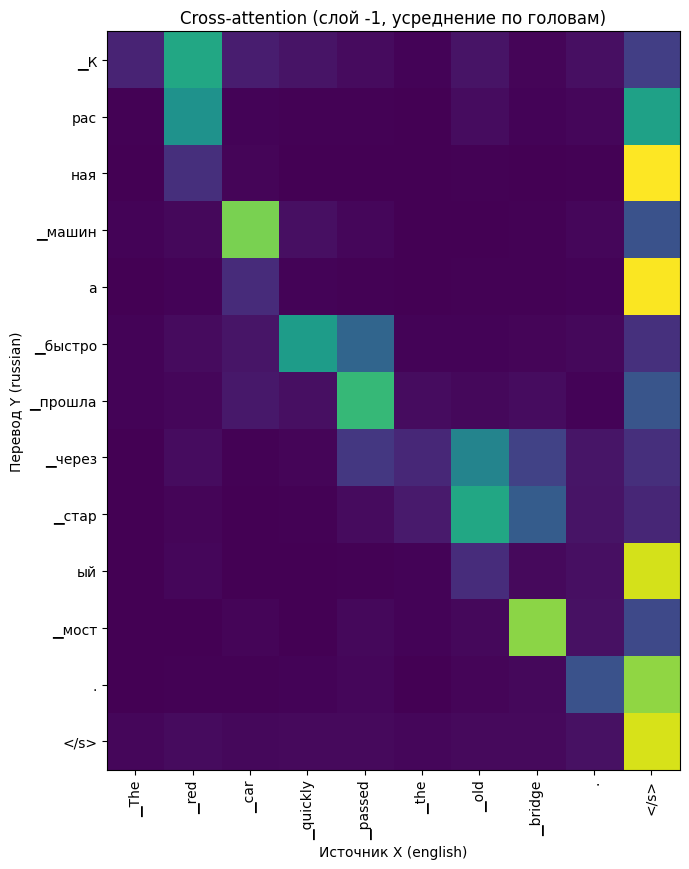

In [8]:
import matplotlib.pyplot as plt

@torch.no_grad()
def cross_attention_matrix(src, layer=-1):
    enc = tokenizer([src], return_tensors="pt").to(device)
    gen = model.generate(**enc, num_beams=1, max_new_tokens=40) # получаем перевод
    out = model(input_ids=enc.input_ids, attention_mask=enc.attention_mask,
                decoder_input_ids=gen, output_attentions=True)
    # cross_attentions: tuple по слоям, берем один слой и усредняем по головам
    attn = out.cross_attentions[layer][0].mean(0).cpu().numpy() # (tgt_len, src_len)
    src_tok = tokenizer.convert_ids_to_tokens(enc.input_ids[0])
    tgt_tok = tokenizer.convert_ids_to_tokens(gen[0])
    attn = attn[:-1] # выкидываем последнюю строку (ей "нечего" порождать после </s>)
    tgt_tok = tgt_tok[1:] # реально сгенерированные токены: gen[1:], без стартового
    return attn, src_tok, tgt_tok

def plot_attention(src, layer=-1):
    attn, src_tok, tgt_tok = cross_attention_matrix(src, layer)
    fig, ax = plt.subplots(figsize=(min(1 + 0.6*len(src_tok), 12),
                                    min(1 + 0.6*len(tgt_tok), 12)))
    ax.imshow(attn, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(src_tok)))
    ax.set_xticklabels(src_tok, rotation=90)
    ax.set_yticks(range(len(tgt_tok)))
    ax.set_yticklabels(tgt_tok)
    ax.set_xlabel("Источник X (english)")
    ax.set_ylabel("Перевод Y (russian)")
    ax.set_title(f"Cross-attention (слой {layer}, усреднение по головам)")
    plt.tight_layout()
    plt.show()

plot_attention("The red car quickly passed the old bridge.")

**Как читать эту диаграмму**

Каждая строка соответствует одному токену, который генерирует декодер. Она показывает, на какие токены входной последовательности модель обращает внимание на этом шаге. Чем ярче клетка, тем выше вес внимания.

**Вопросы**

- Найдите строку с русским "мост". На какой токен входного предложения приходится наибольший вес внимания?
- Видна ли структура, похожая на диагональ? Где она нарушается? Можно ли связать эти отклонения с перестановкой слов при переводе?

Важно! Не стоит слишком буквально интерпретировать такие картинки: cross-attention не является строгой лингвистической разметкой выравнивания. Мы усреднили веса по головам и посмотрели только на один слой, а разные attention heads могут фокусироваться на разных аспектах входа. Поэтому диаграмма дает полезную интуицию о работе модели, но не является доказательством того, что модель "сопоставила" конкретные слова именно таким образом.


## Блок 3. Cтратегии декодирования

**Вопрос**

Модель уже обучена и ее веса зафиксированы. Может ли она выдать разные переводы для одного и того же входа? Если да, откуда берется это разнообразие, если параметры модели не меняются?


Модель задает распределение $P(Y\mid X)$, а не единственный готовый ответ. Конкретный перевод выбирает стратегия декодирования:

- **greedy decoding** - на каждом шаге выбираем самый вероятный токен, результат детерминирован.
- **beam search** - одновременно поддерживаем несколько наиболее перспективных гипотез и выбираем наиболее вероятную последовательность целиком; для машинного перевода это классический подход; на практике часто используют ширину beam 4-8.
- **sampling** - случайным образом выбираем следующий токен из распределения вероятностей (параметры temperature, top-k и top-p позволяют управлять разнообразием и случайностью генерации).

Для машинного перевода обычно важны точность и стабильность, поэтому beam search часто оказывается хорошим выбором. Для чат-ботов и творческой генерации, наоборот, может быть важнее разнообразие, поэтому используют sampling.


In [9]:
src = "The meeting was postponed until next week."
print("X:", src, "\n")

print("greedy:", translate(src, num_beams=1)[0])
print("beam (k=5)", translate(src, num_beams=5)[0])

set_seed(0)
print("sampling T=0.7:", translate(src, do_sample=True, num_beams=1, temperature=0.7, top_p=0.9)[0])
set_seed(1)
print("sampling T=1.3:", translate(src, do_sample=True, num_beams=1, temperature=1.3, top_p=0.95)[0])
set_seed(2)
print("sampling T=1.3:", translate(src, do_sample=True, num_beams=1, temperature=1.3, top_p=0.95)[0])

[transformers] Both `max_new_tokens` (=60) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


X: The meeting was postponed until next week. 



[transformers] Both `max_new_tokens` (=60) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


greedy: Совещание было перенесено на следующую неделю.


[transformers] Both `max_new_tokens` (=60) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


beam (k=5) Совещание было перенесено на следующую неделю.


[transformers] Both `max_new_tokens` (=60) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


sampling T=0.7: Встреча была отложена на следующую неделю.


[transformers] Both `max_new_tokens` (=60) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


sampling T=1.3: Эта встреча перенесена на следующую неделю.
sampling T=1.3: Это совещание было перенесено на следующую неделю.


- При `greedy` и `beam search` при одинаковых настройках результат будет одинаковым при каждом запуске. При `sampling` результаты могут отличаться.
- При высокой температуре (`T=1.3`) генерация становится более случайной, поэтому в переводе могут появляться неожиданные формулировки и ошибки. "Поехал" ли перевод в наших примерах? Это наглядно показывает компромисс между качеством и разнообразием.
- Как изменится выбор стратегии, если изменится задача? Для поддержки пользователей, где важна точность и сохранение исходного смысла, разумнее использовать `greedy` или `beam search`. Для генерации нескольких вариантов заголовков текстов может быть полезен `sampling`. Одна и та же модель может использоваться в разных режимах в зависимости от задачи.


### Teacher forcing: чему равен loss

Вспомним из лекции: обучение seq2seq-модели основано на минимизации кросс-энтропии:

$$\text{Loss}=-\sum_t \log P(y_t\mid y_{<t}, X).$$

При этом во время обучения модель получает правильный префикс $y_{<t}$ - это и есть **teacher forcing**. То есть на каждом шаге она предсказывает следующий токен, опираясь на правильные предыдущие токены, а не на собственные предсказания.

Посчитаем такой loss одним forward-проходом. Он покажет, насколько хорошо модель оценивает эталонный перевод при условии исходного текста. Чем меньше loss, тем выше суммарная вероятность, которую модель присваивает правильным токенам.


In [10]:
@torch.no_grad()
def teacher_forcing_loss(src, ref):
    enc = tokenizer([src], return_tensors="pt").to(device)
    labels = tokenizer(text_target=[ref], return_tensors="pt").input_ids.to(device)
    loss = model(**enc, labels=labels).loss # средняя кросс-энтропия на токен
    return loss.item()

src = "The train to Berlin leaves at seven."
good = "Поезд до Берлина отправляется в семь."
bad = "Поезд до Берлина отправляется в понедельник." # число заменили

print(f"loss (хороший эталон): {teacher_forcing_loss(src, good):.3f}")
print(f"loss (испорченный): {teacher_forcing_loss(src, bad):.3f}")

loss (хороший эталон): 0.244
loss (испорченный): 1.491


In [18]:
@torch.no_grad()
def per_token_logprobs(src, ref):
    enc = tokenizer([src], return_tensors="pt").to(device)
    labels = tokenizer(text_target=[ref], return_tensors="pt").input_ids.to(device)
    logp = model(**enc, labels=labels).logits.log_softmax(-1)[0]          # (T, |V|)
    tok_logp = logp.gather(-1, labels[0].unsqueeze(-1)).squeeze(-1)        # log P(y_t | y_<t, X)
    for tok, lp in zip(tokenizer.convert_ids_to_tokens(labels[0]), tok_logp):
        print(f"{tok:>16s}  log P = {lp.item():6.2f}")
    print(f"{'сумма':>16s}  = {-tok_logp.sum().item():.2f}   среднее на токен = {-tok_logp.mean().item():.3f}")
per_token_logprobs(src, good)
print()
per_token_logprobs(src, bad)

             ▁По  log P =  -7.06
               е  log P =  -1.10
              зд  log P =  -0.04
             ▁до  log P =  -8.62
         ▁Берлин  log P = -11.82
               а  log P =  -0.36
       ▁отправля  log P =  -8.35
            ется  log P =  -1.02
              ▁в  log P =  -0.91
           ▁семь  log P =  -8.84
               .  log P =  -5.14
            </s>  log P =  -0.11
           сумма  = 53.36   среднее на токен = 4.447

             ▁По  log P =  -7.06
               е  log P =  -1.10
              зд  log P =  -0.04
             ▁до  log P =  -8.62
         ▁Берлин  log P = -11.82
               а  log P =  -0.36
       ▁отправля  log P =  -8.35
            ется  log P =  -1.02
              ▁в  log P =  -0.91
    ▁понедельник  log P =  -6.51
               .  log P =  -0.92
            </s>  log P =  -0.11
           сумма  = 46.80   среднее на токен = 3.900


Более высокий loss на испорченном эталоне означает, что модель приписывает этой последовательности меньшую вероятность. Именно такой сигнал используется при обучении: модель учится повышать вероятность правильных продолжений.

**Exposure bias** возникает из-за различия между обучением и генерацией. На обучении модель получает правильный префикс, а при генерации должна опираться на собственные предыдущие предсказания. Поэтому ранняя ошибка может повлиять на все последующие шаги и привести, например, к повторам или потере смысла.

Полностью устранить этот эффект непросто, поэтому на практике важны не только качество самой модели, но и стратегия декодирования.


## Блок 4. Оценка качества через BLEU


В переводе **нет единственного правильного ответа**, поэтому `accuracy` здесь не подходит. Одна и та же мысль может быть корректно переведена разными способами. Идея BLEU и ROUGE - сравнивать n-граммы с эталонными текстами.

**BLEU** (для машинного перевода, ориентирован на precision) учитывает:

- **модифицированную n-граммную точность** для $n=1..4$ с **clipping**: число совпадений каждой n-граммы ограничивается тем, сколько раз она встречается в эталоне, поэтому повторением одного и того же фрагмента нельзя искусственно повысить оценку,
- **геометрическое среднее** точностей для разных $n$,
- **штраф за краткость** (brevity penalty): без него модели было бы выгодно выдавать слишком короткие ответы.

**Важно!** BLEU - **корпусная метрика**. На большом тестовом наборе она позволяет достаточно надежно сравнивать системы, но для отдельного предложения оценка может быть нестабильной. Считать BLEU будем через `sacrebleu` - стандартный инструмент с фиксированной токенизацией, который делает результаты воспроизводимыми и сопоставимыми.

**Наши данные.** Возьмем небольшой параллельный набор EN-RU - собственный, чтобы все примеры были прозрачными и вычисления выполнялись быстро.


In [11]:
# Мини-набор для оценки: (english source, russian reference)
EVAL = [
    ("The weather is nice today.", "Сегодня хорошая погода."),
    ("She bought three apples at the market.", "Она купила три яблока на рынке."),
    ("We need to finish the report before Friday.", "Нам нужно закончить отчёт до пятницы."),
    ("The train to Berlin leaves at seven.", "Поезд до Берлина отправляется в семь."),
    ("He forgot his umbrella at the office.", "Он забыл зонт в офисе."),
    ("This book changed the way I think.", "Эта книга изменила то, как я мыслю."),
    ("They are building a new bridge across the river.", "Они строят новый мост через реку."),
    ("Please turn off the lights when you leave.", "Пожалуйста, выключайте свет, когда уходите."),
    ("The company launched its product last year.", "Компания выпустила свой продукт в прошлом году."),
    ("I have never seen anything like this before.", "Я никогда раньше не видел ничего подобного.")
]
sources = [s for s, _ in EVAL]
refs = [r for _, r in EVAL]
print(f"Пар в наборе: {len(EVAL)}")

Пар в наборе: 10


In [12]:
import sacrebleu

hyp_greedy = translate(sources, num_beams=1)
hyp_beam = translate(sources, num_beams=5)

# sacrebleu: corpus_bleu(гипотезы, [список_эталонов])
bleu_greedy = sacrebleu.corpus_bleu(hyp_greedy, [refs])
bleu_beam = sacrebleu.corpus_bleu(hyp_beam, [refs])

print(f"Corpus BLEU, greedy: {bleu_greedy.score:.2f}")
print(f"Corpus BLEU, beam (k=5): {bleu_beam.score:.2f}")
print("\nПримеры переводов (beam):")
for s, h, r in list(zip(sources, hyp_beam, refs))[:4]:
    print(f"  EN:  {s}\n  HYP: {h}\n  REF: {r}\n")
print("\nПримеры переводов (greedy):")
for s, h, r in list(zip(sources, hyp_greedy, refs))[:4]:
    print(f"  EN:  {s}\n  HYP: {h}\n  REF: {r}\n")

[transformers] Both `max_new_tokens` (=60) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Corpus BLEU, greedy: 63.43
Corpus BLEU, beam (k=5): 74.38

Примеры переводов (beam):
  EN:  The weather is nice today.
  HYP: Сегодня хорошая погода.
  REF: Сегодня хорошая погода.

  EN:  She bought three apples at the market.
  HYP: Она купила три яблока на рынке.
  REF: Она купила три яблока на рынке.

  EN:  We need to finish the report before Friday.
  HYP: Нам нужно закончить отчёт до пятницы.
  REF: Нам нужно закончить отчёт до пятницы.

  EN:  The train to Berlin leaves at seven.
  HYP: Поезд до Берлина отправляется в семь.
  REF: Поезд до Берлина отправляется в семь.


Примеры переводов (greedy):
  EN:  The weather is nice today.
  HYP: Сегодня хорошая погода.
  REF: Сегодня хорошая погода.

  EN:  She bought three apples at the market.
  HYP: Она купила три яблока на рынке.
  REF: Она купила три яблока на рынке.

  EN:  We need to finish the report before Friday.
  HYP: Нам нужно закончить отчёт до пятницы.
  REF: Нам нужно закончить отчёт до пятницы.

  EN:  The train to Ber

- Сравните два результата. Обычно `beam search` дает BLEU не ниже `greedy`, поскольку ищет более вероятную последовательность целиком. При этом разница может быть небольшой - это нормально.
- BLEU принимает значения от 0 до 100. Что считать "хорошим" результатом? Универсального порога нет: значение зависит от языка, домена, данных и способа токенизации. Поэтому BLEU имеет смысл сравнивать только при одинаковом препроцессинге и настройках оценки. Именно поэтому используем `sacrebleu`.


### Ограничения метрики

**Вопрос**

Ваш коллега перевел `The meeting was postponed until next week` как "Собрание отложили до следующей недели" - по-русски это звучит естественно и точно передает исходный смысл. Но как оценит такой перевод автоматическая метрика?

Давайте проверим это и возьмем два одинаково правильных перевода: один почти совпадает с эталоном лексически, другой - верный перефраз.


In [13]:
src = "The meeting was postponed until next week."
ref = "Встреча была перенесена на следующую неделю."
cand_A = "Встреча была перенесена на следующую неделю." # дословно как эталон
cand_B = "Собрание отложили до следующей недели." # верно, но другими словами

print(f"A (дословно) : sentence-BLEU = {sacrebleu.sentence_bleu(cand_A, [ref]).score:5.1f}")
print(f"B (перефраз) : sentence-BLEU = {sacrebleu.sentence_bleu(cand_B, [ref]).score:5.1f}")

A (дословно) : sentence-BLEU = 100.0
B (перефраз) : sentence-BLEU =   6.9


Оба перевода корректны, но у перефраза BLEU резко ниже: в нем мало n-грамм, совпадающих с этим конкретным эталоном. BLEU оценивает поверхностное совпадение текста, а не то, насколько хорошо передан смысл.

Так мы приходим к ограничениям метрики BLEU:

- **Не понимает смысл** - корректный перефраз может получить низкую оценку.
- **Не проверяют факты** - текст, который хорошо совпадает с эталоном по словам, но содержит фактическую ошибку, может получить высокий балл.
- **Зависят от эталонов** - если используется один reference, разнообразие корректных формулировок может недооцениваться.
- **Чувствительны к токенизации** - разные варианты предобработки могут заметно изменить результат, поэтому сравнивать BLEU нужно при одинаковых настройках токенизации.

Поэтому появились метрики, использующие нейросетевые представления: **BERTScore** сравнивает контекстные представления токенов, а **COMET** использует обученную модель для оценки качества машинного перевода. Но и такие метрики не заменяют человеческую оценку полностью.



### Мостик к домашнему заданию: почему для суммаризации будем использовать метрику ROUGE, а не BLEU

* **Перевод:** выход обычно сопоставим по объему с исходным текстом, а одна из ключевых ошибок - добавить лишнее или исказить исходный смысл. Поэтому BLEU, ориентированный на точность совпадения n-грамм, подходит как одна из базовых метрик.
* **Суммаризация:** выход значительно короче исходного текста, поэтому особенно важно не потерять ключевую информацию. Здесь полезен ROUGE, ориентированный на полноту совпадений с эталоном. Например, ROUGE-L оценивает наибольшую общую подпоследовательность.

**Вопрос на подумать**

Подумайте о вашем рабочем или дипломном проекте, где решается задача "текст -> текст". Что дороже: добавить лишнее или потерять важное? От ответа зависит, на какие свойства результата стоит сделать акцент при выборе метрики. Именно эту логику вы примените в ДЗ по суммаризации.


## Итоги

- **Seq2seq - это условная генерация** $P(Y\mid X)=\prod_t P(y_t\mid y_{<t}, X)$. Математическая идея остается знакомой: авторегрессионная LM теперь дополнительно учитывает вход $X$. Перевод, суммаризация и перефразирование относятся к одному общему классу задач.
- **Encoder-decoder + cross-attention.** Энкодер один раз обрабатывает вход, а декодер на каждом шаге обращается к его представлению через cross-attention. Матрица внимания помогает получить интуицию о выравнивании, но не является строгой разметкой alignment.
- **Подсловная токенизация и открытый словарь.** Подсловная токенизация позволяет представлять редкие и незнакомые слова без `<UNK>`. Это особенно важно для имен, чисел и терминов, которые нужно сохранить при генерации.
- **Стратегия декодирования.** `greedy` и `beam search` обычно используют, когда важны стабильность и точность перевода, а `sampling` - когда важнее разнообразие. Веса модели при этом не меняются.
- **BLEU легко посчитать через `sacrebleu`, но интерпретировать нужно осторожно.** Это корпусная метрика, которая оценивает поверхностное совпадение n-грамм и может плохо отражать смысловую близость. Для задач суммаризации акцент часто смещается в сторону полноты, поэтому используют ROUGE.


## Вопросы для рефлексии

1. Если модель правильно переводит редкое имя, что именно помогло ей его сохранить: BPE, cross-attention или стратегия декодирования?

2. Что произойдет с переводом, если увеличить размер beam с 1 до 20? Станет ли перевод обязательно лучше?

3. Почему нельзя просто взять обычную русскую LM и попросить ее перевести английское предложение? Чего ей не хватает?

4. Вы строите систему перевода технической документации. Что важнее сохранить: естественность формулировок или точность терминов, чисел и имен? Как это повлияет на decoding и оценку?
